<a href="https://colab.research.google.com/github/AurelienT430/C_Arduino_coursework/blob/Test/24WSA024_JNB_Arduino_Coursework_Final_2025S2(V1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **24WSA024 Coursework for Arduino Programming**


# **Academic Integrity**

**Your coursework submission must be your own work**

Academic misconduct will not be tolerated. Students should be familiar with [regulation XVIII (academic misconduct)](https://www.lboro.ac.uk/governance/regulations/18/) also detailed in the relevant section in the [student handbook](https://www.lboro.ac.uk/students/handbook/assessments/exams-information/academic-misconduct/).

For coursework, students should be aware of misconduct section vii:

*collusion – working with another student on an assessment which is intended to be the student’s own work. This includes submitting assessed work as the student’s own of which the student is not the sole author (because of the collusion with another student), or providing material which is submitted by another student as their own.*


# **Student Details**

Please fill in the following variables in the code cell below

In [ ]:
#@title student details
coursework_on = False
# do not write above this line ##########################################
# provide text to assign the following variables to your names and id:

firstname  = 'Aurelien'
surname    = 'Toucas'
student_id = 'F430908'
controller_name = ''      # make a name up for the robot controller

# do not write below this line ##########################################

details = {'firstname': firstname, 'surname': surname, 'student_id': student_id, 'controller_name': controller_name }
for key, value in details.items():
  print (f"{key:<20} {value if value else 'not entered'}")
if any([not(v) for v in details.values()]) and coursework_on:
  raise Exception("PLEASE SUPPLY YOUR STUDENT DETAILS")


firstname            Aurelien
surname              Toucas
student_id           F430908
controller_name      not entered


#**Coursework**

This Notebook contains your coursework. It contains details of the tasks to complete and submission details.

**Introduction**

In this coursework, students are required to design a **low-power, dynamically optimized temperature monitoring system** using **Arduino**. The objective is to create an **efficient and responsive system** that minimizes **energy consumption** while ensuring **effective memory management**.

A **smart home environment** relies on a **temperature monitoring system** to regulate room temperature. The system uses a **temperature sensor** to collect real-time data, which is processed by an **Arduino-based controller**. The **CPU** decides whether to activate a **heater** based on temperature readings. This decision is crucial in maintaining a comfortable indoor environment while ensuring energy efficiency. However, if the system continuously samples temperature data at a high frequency, it results in excessive energy consumption. This is because the processor remains active, consuming power even when temperature fluctuations are minimal. Additionally, frequent sensor readings generate a large volume of data, increasing memory usage and slowing down processing. To address these inefficiencies, the system employs dynamic sampling adjustments, allowing it to switch between different power modes based on the rate of temperature change.

**Your Deliverables**

There are **four** main deliverables for this coursework as follows:

1. **Version Control** - Use of Git/Github
2. **Arduino Basics** – Learn Arduino basics, review provided C code, and answer conceptual questions.
3. **Data Analytics**  –Collect temperature data, store it efficiently, and analyze trends using Python, i.e.,visualising data by tabulation and/or using matplotlib
4. **Performance Optimization** – Implement adaptive sampling based on temperature changes to optimize power usage and memory storage.

These are further defined and explained in the specific corresponding coursework releases along with the marking criteria. Please ensure you follow the explicit instructions, and where directed ensure specific variable, function or object names and named/titled code cells are used.



###**Marking Schema**

Marks for each section are assigned as follows. A detailed breakdown is provided in the associated sections below.

| **Section**           | **Description**                                | **Marks** |
|----------------------|---------------------------------------------|---------|
| **Version Control**   | Use of Git/Github. | **15** |
| **Arduino Basics**   | Understanding Arduino fundamentals, reviewing provided C code, and answering conceptual questions. | **20** |
| **Data Analytics**   | Storing temperature data, analyzing trends, and producing tabular and graphical outputs. | **30** |
| **Performance Optimization** | Implementing adaptive sampling and optimizing energy efficiency in real-time temperature monitoring. | **35** |



###**How to Start**

It is important to approach this coursework methodically. A key learning outcome is to understand how to integrate hardware and software in an embedded system, as well as how to develop and optimize an existing system. This does not mean that you must fully understand every line of the provided Arduino code before starting, so do not feel overwhelmed.

First, begin by setting up the Arduino hardware. The system consists of an Arduino board connected to a temperature sensor. You should familiarize yourself with the correct wiring configuration, ensuring that the sensor's **VCC**, **GND**, and **Data Pin** are connected properly to the Arduino. Make sure to verify that the connections are stable before proceeding.

Second, study the provided C code that allows the Arduino to collect temperature readings. Identify key functions responsible for reading sensor data. Try modifying different parameters such as the sampling interval to observe how the system behaves. Work through this step interactively, compile the code, run it on the Arduino, and monitor the output in the serial console.

Next, analyze how the collected data is stored. The system logs temperature readings and outputs them directly to a file on the computer through the serial connection. This file will later be used for analysis in Python. You should understand how the Arduino writes data to the file and how Python will be used to process it.

Once data is collected, students will implement the **Discrete Fourier Transform (DFT)** in C to analyze the dominant temperature change frequencies. This analysis will allow the system to adjust the sampling rate dynamically, ensuring efficient energy use by detecting when high-frequency temperature variations occur.

Finally, after gaining a good understanding of how the system operates, move on to the optimization task. The goal is to implement an adaptive sampling strategy to adjust the system’s power consumption based on temperature fluctuations. The more stable the temperature, the less frequent the readings should be. This ensures that the system runs efficiently without unnecessary energy waste.

Approach this coursework iteratively, test your implementation, analyze the results, and refine your design as needed. By doing so, you will develop both a theoretical and practical understanding of embedded system optimization.




## **The Temperature Monitoring System and Its Three Modes**

The temperature monitoring system acts as an intelligent **environmental regulator**, which continuously assesses temperature fluctuations to determine the optimal response. It operates using an **adaptive control mechanism**, adjusting its **sampling rate and power mode** dynamically to balance energy efficiency and data accuracy.

The **sampling rate** defines how often temperature data is collected. If a fixed high **sampling rate** is used, it leads to **unnecessary energy consumption and excessive data storage**. **Sampling Frequency** refers to the number of samples taken per second when measuring a signal, which is expressed in Hertz (Hz), where 1 Hz = 1 sample per second. For example: If a system samples temperature data at 10 Hz, it means 10 temperature readings are taken every second.

The system features **three operating modes**, each designed to optimize energy use and performance:

1. **Active Mode**: The system enters this mode when **rapid temperature fluctuations** are detected. In this state, the **sampling frequency is high**, allowing for quick responses to environmental changes. This ensures that the system can react promptly, such as turning on a heater when a sudden drop in temperature occurs.

2. **Idle Mode**: When **temperature fluctuations are minor**, the system reduces its sampling frequency to a moderate level. This prevents unnecessary power consumption while still maintaining sufficient responsiveness to gradual temperature changes.

3. **Power Down Mode**: If the temperature remains **stable** over an extended period, the system further reduces its sampling frequency to the lowest level. This significantly **minimizes power consumption**, allowing the system to run efficiently without excessive data logging or energy waste.

Below is an **example** of the three modes, each with a different sampling frequency. The amount of stored temperature data depends on how often the system logs temperature readings.

$$Table1$$

| **Mode**              | **Sampling Rate**        | **Samples Per Hour** | **Samples Per Day** |
|----------------------|------------------------|---------------------|-------------------|
| **Power Down Mode**   | **1 sample per 30 sec** | 120                 | **2,880 samples** |
| **Idle Mode**        | **1 sample per 5 sec**  | 720                 | **17,280 samples** |
| **Active Mode**      | **1 sample per 1 sec**  | 3,600               | **86,400 samples** |

**Interpretation:**
- If the system **stays in Active Mode**, it can generate up to **86,400 data points per day**, which may exceed storage capacity.
- If the system **mostly stays in Power Down Mode**, it will store only **2,880 samples per day**, significantly reducing memory usage.
- Switching between modes **reduces unnecessary logging**, ensuring **only important temperature variations** are recorded.

These **three modes** allow the system to intelligently allocate resources, ensuring that energy is used only when necessary while still capturing relevant environmental data. The transition between modes is governed by **real-time analysis** of temperature trends, ensuring an efficient and adaptive monitoring process. To optimize energy efficiency, this coursework focuses on **dynamic sampling rate adjustments** based on temperature fluctuations.

This coursework contains 4 Tasks. Read the details for each Task below.

# **Task 1: Version Control**
This section is worth 15 marks. The learning objectives are to:
* Provide you with a deep understanding of version control.
* Learn specifically the use of Github and its integration with coding environments such as VSC or Colab
* Develop transferable skills for future coding projects


This task provides hands-on exercises to help students understand and troubleshoot common issues when working with GitHub, Google Colab, Codespaces, and Git branches. You will explore branch management rules in Git and learn how to resolve issues when deleting branches.


Below you will see details of how to set up your account and four distinct elements to this exercise which also provide you with an assessment rubric.

Please note that your Github repository should include this Jupyter notebook and any arduino code, if applicable.

#### **GitHub Account**

Using your **own** login credentials create a Github account. _**We advise you not to use you university password for other third party sites**_

Create a **private** repository for your coursework project.

Upload your Jupyter Notebook Coursework file(s) and create a `README.md` file to document your work. The README file **should** include:

*   Your student ID
*   A brief explanation of your project (your own style, if you have no idea, a report format would be acceptable)
*   A description of the solution for each task (your own style)
*   A list of the files in the repository and their purpose (your own style)

**The format and details in the `README.md` file contribute to your coursework marks.**

 Share the repository with the instructor by **adding their university email as a collaborator**, rather than sharing your repository link via email directly.

Python Coursework

Add Philip (p.a.leicester@lboro.ac.uk) as a collaborator

Arduino Coursework

Add Wenheng (w.zhang2@lboro.ac.uk) as a collaborator

Change the name of the shared repository as `Your_Student_ID_WSA024_Arduino/Python Coursework`. Note we will usually only check in on your Github at the end of the coursework.


#### **Github Best Practice**

You must research the use of Github for your project. For example you can

* Use it merely as a cloud storage
* Manage versions of your code save as new files
* Use Git to manage code updates/modification in the same file allowing comparisons and code commits
* manage branching and merging
* Learn how to integrate it with your coding environment with Github desktop/website.
* Create and manage related documentation such as release notes.

*italicized text*
Read about it

Play with it!

Use it!!!

See the free [e-book](https://git-scm.com/book/en/v2)


### **Task 1.1: Authentication Issues in Google Colab [4 marks]**

In this task, you will explore authentication issues that arise when saving a Jupyter Notebook from Google Colab to a private GitHub repository.

Open [Google Colab](https://colab.research.google.com), upload your Jupyter Notebook coursework file. Click File > Save a copy in GitHub. Select your private repository as the destination. Ensure that the notebook is correctly saved in the GitHub repository. Based on your experience, fix the problem below.

Considering a scenario that a student opens Google Colab and creates a new Jupyter Notebook. They try to save the notebook directly to GitHub but **cannot find their private repository**, only public repositories appear. What is the reason for this issue? How does Google Colab access repositories? What steps are needed to allow Google Colab to save notebooks to your private repositories? How can you verify that your authentication settings are working correctly? *Do not using CodeSpaces to solve this question.*


### **Task 1.1 - Answer**

The reason for this issue is that the repository is private, however by default, Google Colab can only access public repositories. Google Colab can only access the Github repository through an authentication known as OAuth. OAuth is an authorization framework that allows the user to consent to 2 apps interacting on their behalf, without needing a password. It does this by providing access tokens to third party services without exposing user credentials. [1]

Steps to allow Colab to save notebooks to private repository:
1.   Click File > Save a copy in GitHub
2.   Colab should now prompt you to sign in to your GitHub account. This is the Oauth authentication process which will give Colab access to your GitHub repository.
3. Ensure you grant all the correct permissions when authenticating. Tick the check box for "Allow access to private repositories" to grant Colab access to your private repositories as well as the public ones.
4. Select the private repository you want to your notebook into.
5. Everything should work as required now.

In order to verify that the authentication settings are working correctly, you could create a test notebook on Colab and save it on your repository on GitHub. If the save is successful, your authentication is working. Alternatively, you could also just open your private repository on GitHub, and if the notebook file is saved correctly, it means the authentication setting are working correctly.


[1] “What is OAuth? Definition and How It Works,” Fortinet. https://www.fortinet.com/resources/cyberglossary/oauth
‌


###**Task 1.2: Designing a GitHub Action for Automated Task Tracking [3 marks]**

In this task, you will design a GitHub Action workflow that automatically verifies whether you complete the required Git tasks in Task 1.3 and Task 1.4 later. Instead of simply following a guide below, think critically about **what GitHub Actions should check** and **why this automation is useful**.


**Step-by-Step Implementation Order**

To begin, go to your GitHub repository. Create a directory for GitHub Actions (if it doesn't exist).

To create a .github/workflows/ directory within their repository, in CodeSpaces using the command `mkdir -p .github/workflows`.

Once the directory is set up, they need to create a new workflow file inside the `.github/workflows` using `touch .github/workflows/task_verification.yml`.

This file will contain the workflow logic that automates the verification process.

The next step is defining the workflow steps. Open the file `task_verification.yml` and paste the following YAML code.


```yaml
name: Verify Git Tasks

on:
  push:
    branches:
      - main
  pull_request:
    branches:
      - main

jobs:
  check-tasks:
    runs-on: ubuntu-latest
    steps:
      - name: Checkout Repository
        uses: actions/checkout@v3

      - name: Verify Task 1.3 (Branch Deletion)
        run: |
          if git branch -r | grep "origin/test-branch"; then
            echo "❌ Task 1.3: Test branch still exists. Please delete it."
            exit 1
          else
            echo "✅ Task 1.3: Test branch deleted successfully!"
          fi

      - name: Verify Task 1.4 (Merge Conflict Resolution)
        run: |
          if git log --oneline | grep "Resolved merge conflict in project-notes.md"; then
            echo "✅ Task 1.4: Merge conflict resolved successfully!"
          else
            echo "❌ Task 1.4: No merge conflict resolution detected!"
            exit 1
          fi

```


In above GitHub Actions workflow code, students should think critically about how the workflow will determine whether `test-branch` was deleted and how it will confirm the successful resolution of a merge conflict. The workflow should be designed to trigger automatically on `push` and `pull_request` events, ensuring that it runs every time a student pushes changes to the repository.

After writing the workflow, the students need to commit and push it to GitHub using the following commands in Codespaces:

```bash
git add .github/workflows/task_verification.yml
git commit -m "Added GitHub Actions workflow for task verification"
git push origin main
```


Now, your GitHub Actions workflow is in place and ready to track progress.
In task 1.3 and 1.4, students should think critically about how the workflow will determine whether `test-branch` was deleted and how it will confirm the successful resolution of a merge conflict. The workflow should be designed to trigger automatically on `push` and `pull_request` events, ensuring that it runs every time a student pushes changes to the repository.

### **Task 1.3: Unable to Delete a Branch [3 marks]**

This task will help you understand why Git sometimes prevents you from deleting a branch. Now that the workflow built in 1.2 exists, students should attempt to delete a branch and GitHub Actions will check their progress.

Following below steps, using CodeSpaces to create a new branch and delete it. In your GitHub, open **GitHub Codespaces** and navigate to your repository, create a new branch called `test-branch`, using
 ```bash
   git checkout -b test-branch
```
Immediately try to delete it using
```bash
   git branch -d test-branch
   ```
Git will return an error message. What does this message mean? Think about why Git prevents you from deleting the branch. Think about how to properly delete a branch using CodeSpaces and apply the fix. Explain your solutions.


### **Task 1.3 - Answer**

Here is the error message that is returned: " error: cannot delete branch 'test-branch' used by worktree at '/workspaces/C_Arduino_coursework' " \
\
This message means that the "test-branch" cannot be deleted as it causes an error. This error occurs because when test-branch is created, Git sets it as the current working branch (checkout). When you try and delete this current working branch (test-branch), Git doesn't know where to move your working directory, so it returns an error. This also prevents you losing your work or leaving the repository in an inconsistent state. \
\
Therefore, in order to properly delete the branch, you need to switch to another branch first, for example the "main" branch. You can do this by using the line "git checkout main" or replace "main" with the name of any other branch. [2] \
The branch can now be deleted using "git branch -d test-branch", however if there are still unmerged changes this still wouldn't work so you would need to replace the lower case "d" with an upper case "D", as this will force delete the branch. [3] \

[2] B. Wakefield, “How can I delete the current Git branch?,” Stack Overflow, Jan. 05, 2017. https://stackoverflow.com/questions/41492254/how-can-i-delete-the-current-git-branch \
[3] A. Yadav, “Force-delete a branch in Git?,” Stack Overflow, Dec. 29, 2016. https://stackoverflow.com/questions/41379997/force-delete-a-branch-in-git
‌


### **Task 1.4: Handling a Merge Conflict in Git [5 marks]**

This task will guide you through intentionally creating a merge conflict in Git, analyzing the issue, and resolving it. By the end of this exercise, you will understand what causes a merge conflict, how to identify and analyze it, and how to resolve it efficiently in a collaborative version control workflow. **Instead of** modifying `README.md`, you will create a new markdown file to avoid interfering with important repository documentation.


Start by opening GitHub Codespaces and navigating to your repository. Create a new branch by running `git checkout -b feature-branch`. Create a new markdown file named `project-notes.md` by running `echo "Initial notes for the project." > project-notes.md`. Open the file in a text editor and modify its content by adding the line `"This is an update from feature-branch."`, then save the file. Stage and commit the change using `git add project-notes.md` and `git commit -m "Updated project-notes.md from feature-branch"`. Push this branch to GitHub with git push origin feature-branch.

Now, switch back to the main branch using `git checkout main` and create a markdown file named `project-notes.md` in the main branch. Modify the file by adding the line `"This is an update from main."` and save the file. Commit the change using `git add project-notes.md` and `git commit -m "Updated project-notes.md from main"`, then push the changes with `git push origin main`. At this point, you have two separate changes in the same file, one in main and one in feature-branch.

Attempt to merge feature-branch into main by running `git merge feature-branch`. Git will reject the merge and display an error indicating a merge conflict in project-notes.md. This occurs because the same file was modified differently in both branches, and Git does not know which version to keep.

Think about how to solve the conflict using CodeSpaces, provide your git code
of solving the conflict. After solve this conflict, commit message in CodeSpaces that says `"Resolved merge conflict in project-notes.md"`, and this action will be checked by the GitHub Actions in Task 1.2.

 What caused the merge conflict in this scenario? Why does Git prevent automatic merging when conflicts occur? How can you prevent merge conflicts when working in a team environment? What steps can you take to check for conflicts before merging changes? What are the consequences of forcing a push without resolving a merge conflict?

 Once the workflow in Task 1.2 runs, the students should navigate to the Actions tab in GitHub to review the logs and verify if their implementation correctly tracks branch deletions and merge conflict resolutions in Task 1.3 and 1.4.

1. Go to the GitHub repository.
2. Click on the "Actions" tab (at the top of the repo).
3. Look for the workflow named "Verify Git Tasks".
4. Click on the latest run.
5. Expand the logs for each step to see if the you deleted the test-branch or resolved the merge conflict.

If everything was done correctly, you will see:
*   ✅ Task 1.3: Test branch deleted successfully!

*   ✅ Task 1.4: Merge conflict resolved successfully!


# **Task 2: Arduino Temperature Sensor Data Collection**

In this task, students will build an **Arduino-based temperature monitoring system** that collects and logs temperature data using the **Grove - Temperature Sensor V1.2**.

The objective is to:

1. **Set up the hardware** and connect the temperature sensor to the Arduino. Build communications between the sensor and the Arduino, to read real-time temperature values. **Task 1.1 [5 marks]**

To complete this task, you need the following components:

- **Arduino board**
- **Grove Temperature Sensor**

Connect the temperature sensor to the Arduino as follows:

| **Grove Temperature Sensor Pin** | **Arduino Connection** |
|-------------------------------|---------------------|
| VCC                           | 5V                 |
| GND                           | GND                |
| Signal                        | A0 (Analog Pin)    |


2. **Log the collected data** read and self-learn from the code below and the provided website, and understand how to process it for further analysis, the student also need to answer the multiple choice questions based on the understanding.



## **Provided Arduino Code**

The following Arduino program is provided in order to enable you to get the temperature sensor working. It reads temperature values from the sensor and prints them to the **Serial Monitor**. You should download the Arduino IDE to run the code. The university computer Lab WPL107 installed the software, and you can also find it via [Arduino IDE](https://www.arduino.cc/en/software). The tutorials on using Arduino Software tools are available from: [Software tools](https://docs.arduino.cc/software/ide-v1/tutorials/Environment/). Connect your Arduino board and temperature sensor, then using Arduino IDE to run the code below to see how it works.

The demo code is avaliable from [seedstudio](https://wiki.seeedstudio.com/Grove-Temperature_Sensor_V1.2)

```c
//
// Loovee @ 2015-8-26

#include <math.h>

const int B = 4275000;            // B value of the thermistor
const int R0 = 100000;            // R0 = 100k
const int pinTempSensor = A0;     // Grove - Temperature Sensor connect to A0

#if defined(ARDUINO_ARCH_AVR)
#define debug  Serial
#elif defined(ARDUINO_ARCH_SAMD) ||  defined(ARDUINO_ARCH_SAM)
#define debug  SerialUSB
#else
#define debug  Serial
#endif

void setup()
{
    Serial.begin(9600);
}

void loop()
{
    int a = analogRead(pinTempSensor);

    float R = 1023.0/a-1.0;
    R = R0*R;

    float temperature = 1.0/(log(R/R0)/B+1/298.15)-273.15; // convert to temperature via datasheet

    Serial.print("temperature = ");
    Serial.println(temperature);

    delay(100);
}
```

Read above code and learn from the provided website, then answer the following questions.

### **Evidence of hardware connection**
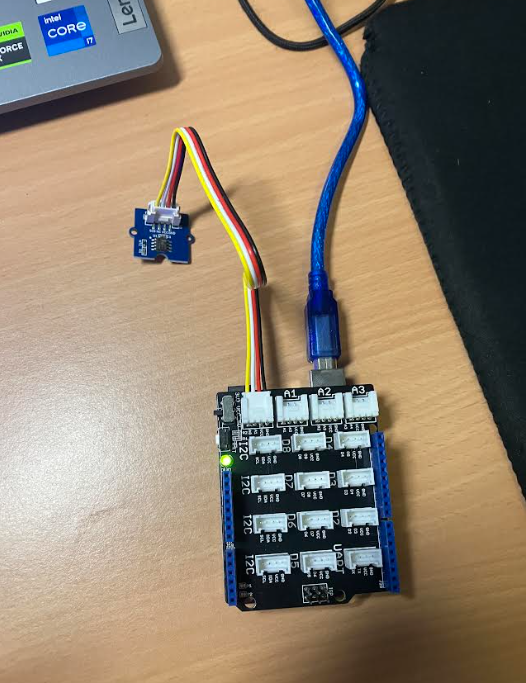

### **Log of Collected Data for 30 seconds**

temperature = 24.14

temperature = 24.14

temperature = 24.14

temperature = 24.26

temperature = 24.23

temperature = 24.23

temperature = 24.23

temperature = 24.28

temperature = 24.94

temperature = 24.51

temperature = 25.06

temperature = 24.87

temperature = 24.78

temperature = 25.24

temperature = 24.99

temperature = 24.83

temperature = 25.33

temperature = 24.97

temperature = 25.36

temperature = 25.45

temperature = 25.52

temperature = 25.61

temperature = 25.63

temperature = 25.70


temperature = 25.72

temperature = 25.79

temperature = 25.61

temperature = 25.56

temperature = 25.52

temperature = 25.49

## **📌 Task 2.1**

**Read above code and learn from the provided website, then answer the following questions.**


In [ ]:
#@title Answer 2.1 Grove Temperature Sensor Questions

# Do not change the title above or duplicate this cell.
# Do not change any of the variable names below or you may lose the marks
# To answer a question, choose the correct dictionary key
# and use it inside the dictionary lookup brackets.
# do not write above this comment
################################################################################

# What type of sensor is the Grove Temperature Sensor?
a2_1_1_ans = {0: "unanswered",
               1: "Thermocouple",
               2: "NTC Thermistor",
               3: "Infrared Sensor",
               4: "Capacitive Sensor"
               }[2]

# What does `analogRead(pinTempSensor);` return?
a2_1_2_ans = {0: "unanswered",
               1: "A digital temperature value",
               2: "A raw voltage value (0-1023)",
               3: "A resistance value",
               4: "A Fahrenheit reading"
               }[2]

# Why do we use the logarithm function `log(R/R0)` in the calculation?
a2_1_3_ans = {0: "unanswered",
               1: "To convert temperature into resistance",
               2: "To linearize the thermistor response using the Steinhart-Hart equation",
               3: "To amplify the sensor signal",
               4: "To filter noise from the reading"
               }[2]

# What is the purpose of `Serial.begin(9600);` in the setup function?
a2_1_4_ans = {0: "unanswered",
               1: "To initialize communication between Arduino and Serial Monitor",
               2: "To set the baud rate of the temperature sensor",
               3: "To configure the analog pin",
               4: "To calibrate the sensor"
               }[1]

# Why is the delay of 100 milliseconds (`delay(100);`) used in the loop?
a2_1_5_ans = {0: "unanswered",
               1: "To improve sensor accuracy",
               2: "To prevent excessive readings that flood the Serial Monitor",
               3: "To allow the sensor to cool down",
               4: "To increase the sampling frequency"
               }[2]

# What does the line `float R = 1023.0/a-1.0;` compute?
a2_1_6_ans = {0: "unanswered",
                1: "The raw temperature value from the sensor",
                2: "The resistance of the thermistor",
                3: "The temperature in Fahrenheit",
                4: "The ADC voltage value"
                }[2]

# What will happen if the `analogRead(pinTempSensor);` function is removed from the loop?
a2_1_7_ans = {0: "unanswered",
                1: "The sensor will stop measuring temperature",
                2: "The Serial Monitor will still display correct readings",
                3: "The temperature will increase",
                4: "It will improve system performance"
                }[1]

# What is the main function of the `float temperature` variable?
a2_1_8_ans = {0: "unanswered",
                1: "Stores the raw ADC reading",
                2: "Stores the computed temperature in Celsius",
                3: "Stores the sensor calibration value",
                4: "Stores the voltage reference value"
                }[2]

# What is the role of the `B` constant in the formula?
a2_1_9_ans = {0: "unanswered",
                1: "It represents the temperature coefficient of the thermistor",
                2: "It is used to calibrate the sensor output",
                3: "It defines the thermistor resistance at 0°C",
                4: "It is used to scale the ADC reading"
                }[1]

# What happens if the thermistor is disconnected?
a2_1_10_ans = {0: "unanswered",
                1: "The temperature reading becomes zero",
                2: "The temperature reading becomes unstable or returns an error",
                3: "The Arduino stops working",
                4: "The resistance reading becomes infinite"
                }[2]

# Hard Question: How can we improve the accuracy of temperature readings?
a2_1_11_ans = {0: "unanswered",
                1: "Use a moving average filter",
                2: "Use a low-pass filter",
                3: "Increase the resolution of ADC readings",
                4: "All of the above"
                }[4]

# Hard Question: What is the best way to store long-term temperature data?
a2_1_12_ans = {0: "unanswered",
                1: "Use EEPROM",
                2: "Use an SD card module",
                3: "Use Serial Monitor only",
                4: "Store in volatile memory"
                }[2]

# What is the correct way to modify the code to log data in CSV format?
a2_1_13_ans = {0: "unanswered",
                1: "Use Serial.print() with comma-separated values and save via Serial Monitor",
                2: "Save data in JSON format",
                3: "Use EEPROM memory to store structured data",
                4: "Directly store in hexadecimal format"
                }[1]

# True or False: The sensor always gives perfect readings without any noise.
a2_1_14_ans = {0: "unanswered",
                1: "True",
                2: "False"
                }[2]

# What modification can be made to take temperature readings every 2 seconds instead of 100ms?
a2_1_15_ans = {0: "unanswered",
                1: "Change `delay(100);` to `delay(2000);`",
                2: "Change `Serial.begin(9600);` to `Serial.begin(4800);`",
                3: "Modify the B value in the formula",
                4: "Increase the ADC resolution"
                }[1]

# do not write below this comment ##############################################
# You may get a zero mark if this cell does not run.
# You can run the cell to check it and your answers.

a1p1_answers = [
    a2_1_1_ans, a2_1_2_ans, a2_1_3_ans, a2_1_4_ans, a2_1_5_ans,
    a2_1_6_ans, a2_1_7_ans, a2_1_8_ans, a2_1_9_ans, a2_1_10_ans,
    a2_1_11_ans, a2_1_12_ans, a2_1_13_ans, a2_1_14_ans, a2_1_15_ans
]

print("\n".join([ f"{'a2_1_' + str(i):<10} :"  +   repr(a) for i, a in enumerate(a1p1_answers,1)]))

# 15 Marks (1 per question)


a2_1_1     :'NTC Thermistor'
a2_1_2     :'A raw voltage value (0-1023)'
a2_1_3     :'To linearize the thermistor response using the Steinhart-Hart equation'
a2_1_4     :'To initialize communication between Arduino and Serial Monitor'
a2_1_5     :'To prevent excessive readings that flood the Serial Monitor'
a2_1_6     :'The resistance of the thermistor'
a2_1_7     :'The sensor will stop measuring temperature'
a2_1_8     :'Stores the computed temperature in Celsius'
a2_1_9     :'It represents the temperature coefficient of the thermistor'
a2_1_10    :'The temperature reading becomes unstable or returns an error'
a2_1_11    :'All of the above'
a2_1_12    :'Use an SD card module'
a2_1_13    :'Use Serial.print() with comma-separated values and save via Serial Monitor'
a2_1_14    :'False'
a2_1_15    :'Change `delay(100);` to `delay(2000);`'


# **Task 3: Data Analysis Using Discrete Fourier Transform (DFT)**

In this task, students will **analyse temperature sensor data** by applying the **Discrete Fourier Transform (DFT)**.

The objective is to:

1. **Understanding the DFT function**, **applying the DFT on collected data** to analyze the frequency components.

2. **Implement functions** for temperature collection and data transmission.

3. **Store the collected time-domain data and transferred frequency domain data** in a .CSV file.

4. **Visualizing the data** by plotting both **time-domain** and **frequency-domain** graphs in Python.

**Please follow specific instructions below for including your Python elements in this workbook**


### **Understanding the Discrete Fourier Transform (DFT) Function**

Before implementing the **DFT function**, students need to self-study the theroy below to understand how the **Discrete Fourier Transform (DFT)** works and how to apply it to temperature data.

#### **Concept of DFT**
The **Discrete Fourier Transform (DFT)** converts a **time-domain signal** (temperature readings over time) into a **frequency-domain representation** (how frequently the temperature changes).

The formula for computing the magnitude of the frequency compinents is:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi k n / N} \text{(eq.3.1)}$$

Where:
- $X[k]$ = Frequency component at index $ k $
- $ x[n] $ = Temperature data at index $ n $
- $ N $ = Total number of samples
- $k $ = Frequency index (ranging from $0 $ to $ N-1 $ )
- $ j $ = Imaginary unit $ \sqrt{-1}$


The index \( k \) in the DFT output represents the frequency component of the original signal, but to obtain actual frequency values in Hz, we use the following equation:

$$f_k = \frac{k \cdot f_s}{N} \quad \text{(eq.3.2)}$$

where:
- $ f_k $ is the frequency corresponding to index $ k$.
- $ f_s $ is the sampling frequency (in Hz).
- $ N $ is the total number of samples.

Since **Arduino does not support complex numbers**, so we implement the real and imaginary parts using two arrays:
- **Real part:** Stores the cosine components of the transformation.

$$ \text{real}[k] = \sum_{n=0}^{N-1} x[n] \cdot \cos\left(\frac{2\pi k n}{N}\right) (eq.3.3)$$

- **Imaginary part:** Stores the sine components.

$$ \text{imag}[k] = -\sum_{n=0}^{N-1} x[n] \cdot \sin\left(\frac{2\pi k n}{N}\right) (eq.3.4)$$

- The magnitude of the frequency components is then calculated as:

$$ \text{Magnitude}[k] = \sqrt{\text{real}[k]^2 + \text{imag}[k]^2}   (eq.3.5) $$



---

[link text](https://)[link text](https://)### **📌 Task 3: Implementing Functions in Arduino IDE**

This sections sets out your tasks for coding the arduino using the standard Arduino IDE. Insert your final code for this task 3 in to the code cell below titled 'task 3 Arduino Code'

#### **Task 3.1**
Based on the provided code in Task 2, rewrite it by introducing a function called `collect_temperature_data()` to collect the temperature from the Grove Temperature Sensor for around 3 minutes, and save it in an array for DFT processing later. Ensure the loop function calls `collect_temperature_data()` correctly. The function should use suitable sampling intervals for collecting data. You can assume we are in the active mode, the sampling rate as Table 1 (see above).

**Hint:** Consider how to manage **fixed sampling intervals** using `delay()` to maintain accurate sampling.

**(3 Marks)**  

---

#### **Task 3.2**
Write a function called `apply_dft()` that applies Discrete Fourier Transform (DFT) in eq.3.1 - eq.3.5 on the collected temperature data in Task 3.1 to convert the signal into frequency-domain components. The function should return the computed frequency (eq.3.2) as a **pointer**. The magnitude of the frequency components should be **calculated and stored** as eq.3.5.

**(6 Marks)**  

---

#### **Task 3.3**
Write a function called `send_data_to_pc()` that sends time-domain and frequency-domain data via the Serial Monitor. The function should print time-domain temperature values. Compute the DFT magnitude spectrum and send the computed frequency values. Send frequency-domain data to the Serial Monitor for further analysis.

**Hint:** The format should be **Time, Temperature, Frequency, Magnitude**.  

**(3 Marks)**  

---

#### **Task 3.4**
Write a function `decide_power_mode()` that determines whether the system should **operate in Active, Idle, or Power-down mode** based on the collected temperature in Task 3.1 and calculated average temperature fluctuation frequency of Task 3.2.

If the average frequency is> 0.5 Hz, use a high sampling rate (Active Mode).
If 0.1 Hz < average frequency ≤ 0.5 Hz, use a medium sampling rate (Idle Mode).
If the average frequency is ≤ 0.1 Hz, switch to Power-down Mode (low sampling rate to conserve energy).

The function should **return a mode indicator** (`ACTIVE`, `IDLE`, or `POWER_DOWN`) based on the computed frequency.

**(6 Marks)**  

---

#### **Task 3.5**
**Save the time-domain and frequency-domain data in a CSV file.**   

The CSV file should store Four columns: **time in the first column, temperature values over 3 minutes in the second column, frequency components in the third column, and corresponding magnitude values in the fourth column**. The file should be named `threeminstemperature_Student_ID.csv`.

**(5 Marks)**

---

#### **Task 3.6**
After storing the temperature data in the .CSV file, use Python to read and visualize the saved data in the .CSV document and plot the **frequency components under the frequency domain**, and the 3-minute temperature under the time domain. Discuss your findings in the above figures.  

**Hint:** This part should be programmed using Python!  


**(7 Marks)**




In [ ]:
#@title Answer Tasks 3.1 to 3.4 Arduino Code
%%script false --no-raise-error
'''
paste your arduino code here for your assessment. Failure to copy your code here
may result in zero marks
'''
# Note this cell should not be run

# do not write or change above this line or duplicate this code cell
################################################################################


#include <math.h>
#include <stdlib.h>

const int B = 4275000;
const int R0 = 100000;
const int pinTempSensor = A0;

const int sampleDuration = 60;
const int sampleInterval = 1;
const int sampleCount = sampleDuration / sampleInterval;

enum PowerMode { ACTIVE, IDLE, POWER_DOWN };

#if defined(ARDUINO_ARCH_AVR)
#define debug Serial
#elif defined(ARDUINO_ARCH_SAMD) || defined(ARDUINO_ARCH_SAM)
#define debug SerialUSB
#else
#define debug Serial
#endif

float read_temperature() {
    int a = analogRead(pinTempSensor);
    float R = 1023.0 / a - 1.0;
    R = R0 * R;
    float temperature = 1.0 / (log(R / R0) / B + 1 / 298.15) - 273.15;
    return temperature;
}

void collect_temperature_data(float* data, int count) {
    for (int i = 0; i < count; i++) {
        *(data + i) = read_temperature();
        delay(1000);
    }
}

void apply_dft(float* input, float* real, float* imag, float* magnitude, float* frequency, int N, float fs) {
    for (int k = 0; k < N; k++) {
        *(real + k) = 0.0;
        *(imag + k) = 0.0;

        for (int n = 0; n < N; n++) {
            float angle = 2 * PI * k * n / N;
            *(real + k) += *(input + n) * cos(angle);
            *(imag + k) -= *(input + n) * sin(angle);
        }

        *(magnitude + k) = sqrt(*(real + k) * *(real + k) + *(imag + k) * *(imag + k));
        *(frequency + k) = k * fs / N;
    }
}

void send_data_to_pc(float* timeData, float* freqData, float* magnitudes, int N, float sampleRate) {
    Serial.println("Time (s),Temperature (C),Frequency (Hz),Magnitude");

    for (int i = 0; i < N; i++) {
        float time = i * (1.0 / sampleRate);
        Serial.print(time, 2);
        Serial.print(",");
        Serial.print(*(timeData + i), 2);
        Serial.print(",");
        Serial.print(*(freqData + i), 2);
        Serial.print(",");
        Serial.println(*(magnitudes + i), 2);
        delay(10);
    }

    Serial.println("---- Data transmission complete ----");
}

PowerMode decide_power_mode(float* magnitudes, float* frequencies, int N) {
    float weightedSum = 0.0;
    float totalMagnitude = 0.0;

    for (int i = 1; i < N; i++) {
        weightedSum += *(magnitudes + i) * *(frequencies + i);
        totalMagnitude += *(magnitudes + i);
    }

    float averageFrequency = 0.0;
    if (totalMagnitude > 0.0) {
        averageFrequency = weightedSum / totalMagnitude;
    }

    Serial.print("Average frequency: ");
    Serial.print(averageFrequency, 3);
    Serial.println(" Hz");

    if (averageFrequency > 0.5) {
        return ACTIVE;
    } else if (averageFrequency > 0.1) {
        return IDLE;
    } else {
        return POWER_DOWN;
    }
}

void setup() {
    Serial.begin(115200);
    while (!Serial);
    delay(1000);
    Serial.println("Starting temperature DFT monitor...");
}

void loop() {
    float* temperatureData = (float*)malloc(sampleCount * sizeof(float));
    float* real = (float*)malloc(sampleCount * sizeof(float));
    float* imag = (float*)malloc(sampleCount * sizeof(float));
    float* magnitude = (float*)malloc(sampleCount * sizeof(float));
    float* frequency = (float*)malloc(sampleCount * sizeof(float));

    if (!temperatureData || !real || !imag || !magnitude || !frequency) {
        Serial.println("Memory allocation failed!");
        while (1);  // Stop execution

    }

    collect_temperature_data(temperatureData, sampleCount);
    apply_dft(temperatureData, real, imag, magnitude, frequency, sampleCount, 1.0);
    send_data_to_pc(temperatureData, frequency, magnitude, sampleCount, 1.0);

    PowerMode mode = decide_power_mode(magnitude, frequency, sampleCount);

    switch (mode) {
        case ACTIVE:
            Serial.println("System Mode: ACTIVE");
            break;
        case IDLE:
            Serial.println("System Mode: IDLE");
            break;
        case POWER_DOWN:
            Serial.println("System Mode: POWER_DOWN");
            break;
    }

    Serial.println("---- Cycle complete. Restarting... ----");
    delay(100);

    free(temperatureData);
    free(real);
    free(imag);
    free(magnitude);
    free(frequency);
}



In [ ]:
#@title Answer for task 3.5

# Explain your solution steps for Task 3.5 as a docstring below.
# The title is already provided

'''

Explanation for Task 3.5

From the above code, the 4 columns (time, temperature, frequency and magnitude) are printed out in the Serial Monitor. I started a 3 minute timer and let the code run. After the 3 minutes have gone by, all the collected data is printed in the serial monitor. I then copy this data onto a Microsoft Excel sheet. The table is formatted to ensure it matches the required format. It is then saved under the file name threeminstemperature_F430908.csv.


'''





'\n\nExplanation for Task 3.5\n\nFrom the above code, the 4 columns (time, temperature, frequency and magnitude) are printed out in the Serial Monitor. I started a 3 minute timer and let the code run. After the 3 minutes have gone by, all the collected data is printed in the serial monitor. I then copy this data onto a Microsoft Excel sheet. The table is formatted to ensure it matches the required format. It is then saved under the file name threeminstemperature_F430908.csv.\n\n\n'

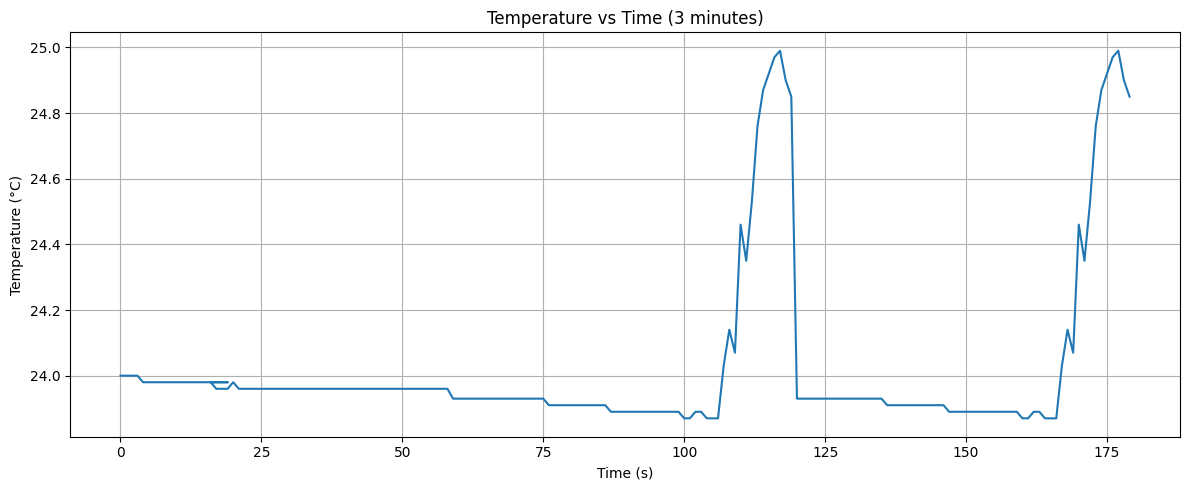

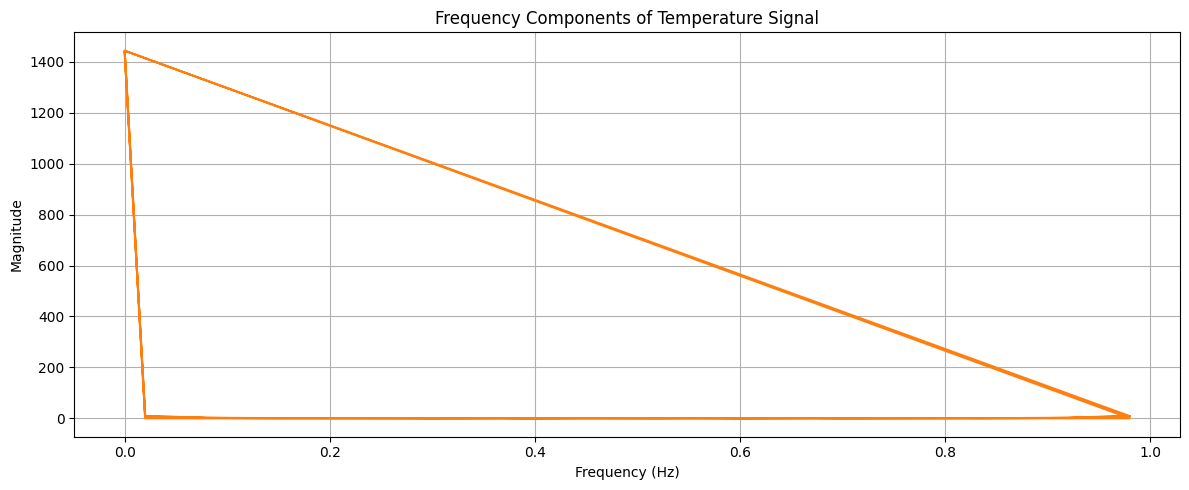

In [ ]:
#@title Answer for task 3.6
# Write your Python code here
#
# NOTE - Only this code cell and outputs will be assessed for task 3.6. Any
# code you produce, including support functions or required imports must be in
# this cell otherwise the assessment scripts might not be able to evaluate your
# code.
#
# Note this cell must read your csv file uploaded with your submission and
# should run!


import pandas as pd
import matplotlib.pyplot as plt

# Load and clean the data
file_path = '/threeminstemperature_F430908.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1', usecols=[0, 1, 2, 3])  # only load first 4 columns
df.columns = ['Time (s)', 'Temperature (°C)', 'Frequency (Hz)', 'Magnitude']

# --- Time Domain Plot ---
plt.figure(figsize=(12, 5))
plt.plot(df['Time (s)'], df['Temperature (°C)'], color='tab:blue')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time (3 minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Frequency Domain Plot ---
# Drop rows with NaN in frequency/magnitude (if any)
freq_df = df[['Frequency (Hz)', 'Magnitude']].dropna()

plt.figure(figsize=(12, 5))
plt.plot(freq_df['Frequency (Hz)'], freq_df['Magnitude'], color='tab:orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Components of Temperature Signal')
plt.grid(True)
plt.tight_layout()
plt.show()


# **Task 4: Adaptive Sampling Rate Optimization (35 marks)**

In this task, students will develop an intelligent temperature monitoring system that dynamically adjusts its sampling rate and power mode based on real-time temperature variations. The system will progressively transition between three power modes: Active Mode, Idle Mode, and Power Down Mode to optimize energy consumption while ensuring accurate temperature tracking. The key challenge is to implement a two-stage decision process that determines both the appropriate power mode and the optimal sampling rate based on temperature trends and frequency analysis.

Consider a scenario that the room temperature changes dynamically due to external factors (heater, air conditioner, or human influence).  
Instead of using a fixed sampling rate in Task 3 and Table 1, your system should adjust its sampling rate dynamically based on observed temperature fluctuations.

The system starts by collecting temperature data for one minute (one cycle) at an initial sampling rate (the students have the freedom to select the initial sampling rate). The collected data is then analyzed to determine whether temperature fluctuations are significant. This is done by computing the total difference between consecutive samples to assess how much the temperature changes over time. If the variation remains within a small predefined threshold (again, in the design, students need to define the threshold value based on their collected temperature data), the system switches to Idle Mode to reduce power consumption. If Idle Mode persists for five consecutive cycles, indicating long-term stability, the system enters Power Down Mode to further conserve energy. However, if a sudden temperature fluctuation occurs at any stage, the system immediately reactivates Active Mode to ensure accurate monitoring.  Additionally, Discrete Fourier Transform analysis is used to detect dominant frequency components, dynamically adjusting the sampling rate based on real-time temperature trends. This adaptive strategy prevents unnecessary high-frequency sampling when the environment remains stable, while ensuring quick responsiveness to sudden changes, ultimately balancing accuracy and power efficiency.

To further refine the decision-making process, DFT extracts dominant frequency components from the temperature variations. By transforming the data into the frequency domain, the system can identify periodic patterns in temperature changes. The DC component (k = 0), representing the overall average temperature, should be ignored, and only frequency components relevant to temperature fluctuations should be considered. The dominant frequency will be used as a reference to adjust the sampling rate dynamically.

Once the system determines whether to operate in Active, Idle, or Power Down Mode, the sampling rate must be adjusted dynamically. The dominant frequency extracted from apply_dft() in your Task 3 should be rewrite to guide this adjustment. The sampling rate must be at least twice the dominant frequency to satisfy **Nyquist’s sampling theorem** and avoid data loss. For instance, if the dominant frequency is 1.8 Hz, the sampling rate should be 3.6 Hz or higher. However, if temperature variations remain stable, the sampling rate should gradually decrease to minimize energy usage. The system must ensure the sampling rate remains within a predefined range, such as between 0.5 Hz and 4.0 Hz, to maintain efficiency.

A future temperature variation trend must also be predicted using a moving average method. Students should track temperature variation trends over the last 5 to 10 monitoring cycles and compute a moving average based on the last 10 temperature differences. This prediction helps determine whether temperature fluctuations are increasing, decreasing, or remaining stable, which directly influences the choice of power mode. If the predicted variation is large, the system remains in Active Mode; if it is moderate, the system enters Idle Mode. If temperature fluctuations stay consistently low for five consecutive cycles, the system transitions into Power Down Mode to further conserve energy. To learn how to implementation of the moving average in Arduino, please refer to: https://www.aranacorp.com/en/implementation-of-the-moving-average-in-arduino/

In addition to power mode optimization, students must also consider memory storage limitations. Since Arduino devices have limited RAM, inefficient storage can lead to system failures. Students must evaluate how memory is utilized in their implementation and identify ways to optimize storage.

---

### **Expected System Behavior**

1. It **analyzes the variations of collected temperature** to determine if the temperature is fluctuating significantly.
2. **DFT is applied** to find the **dominant frequency** of temperature variations.💡
3. **The best power mode is selected** based on predicted variations.
4. **Adjust the sampling rate dynamically** to reduce **power consumption** while maintaining accurate monitoring.
5. A **future variation trend is predicted** using a moving average.
6. Explain how memory is utilized in your implementation of Task 4. Are there any memory optimizations that could be made to reduce usage? What is the impact of storing large arrays in an Arduino environment? Provide a justified explanation and suggest at least one possible enhancement to improve memory efficiency in this coursework.


---

### **📌 Example of Sample Serial Outputs (Feel free to design your own outputs)**

```
Collecting temperature data for 1 minute...
Predicted Variation: 4.20, Dominant Frequency: 1.80 Hz, New Sampling Rate: 2.70 Hz, Power Mode: ACTIVE

Collecting temperature data for 1 minute...
Predicted Variation: 1.80, Dominant Frequency: 1.00 Hz, New Sampling Rate: 1.00 Hz, Power Mode: IDLE

Collecting temperature data for 1 minute...
Predicted Variation: 0.40, Dominant Frequency: 0.30 Hz, New Sampling Rate: 0.50 Hz, Power Mode: POWER_DOWN


In [ ]:
#@title Answer for task 4.0
%%script false --no-raise-error
'''
paste your task 4 arduino code here for your assessment. Failure to copy your code here may result in zero marks
'''
# Note this cell should not be run

# do not write or change above this line or duplicate this code cell
################################################################################

#include <math.h>
#include <stdlib.h>

const int B = 4275000;
const int R0 = 100000;
const int pinTempSensor = A0;

const int sampleDuration = 60;

const float ACTIVE_RATE = 1.0;
const float IDLE_RATE = 0.2;
const float POWER_DOWN_RATE = 1.0 / 30.0;

const int ACTIVE_INTERVAL_MS = 1000;
const int IDLE_INTERVAL_MS = 5000;
const int POWER_DOWN_INTERVAL_MS = 30000;

enum PowerMode { ACTIVE, IDLE, POWER_DOWN };

#if defined(ARDUINO_ARCH_AVR)
#define debug Serial
#elif defined(ARDUINO_ARCH_SAMD) || defined(ARDUINO_ARCH_SAM)
#define debug SerialUSB
#else
#define debug Serial
#endif

float read_temperature() {
    int a = analogRead(pinTempSensor);
    float R = 1023.0 / a - 1.0;
    R = R0 * R;
    float temperature = 1.0 / (log(R / R0) / B + 1 / 298.15) - 273.15;
    return temperature;
}

void collect_temperature_data(float* data, int count, int interval_ms) {
    for (int i = 0; i < count; i++) {
        data[i] = read_temperature();
        delay(interval_ms);
    }
}


void apply_dft(float* input, float* real, float* imag, float* magnitude, float* frequency, int N, float fs) {
    for (int k = 0; k < N; k++) {
        *(real + k) = 0.0;
        *(imag + k) = 0.0;

        for (int n = 0; n < N; n++) {
            float angle = 2 * PI * k * n / N;
            *(real + k) += *(input + n) * cos(angle);
            *(imag + k) -= *(input + n) * sin(angle);
        }

        *(magnitude + k) = sqrt(*(real + k) * *(real + k) + *(imag + k) * *(imag + k));
        *(frequency + k) = k * fs / N;
    }
}

void send_data_to_pc(float* timeData, float* freqData, float* magnitudes, int N, float sampleRate) {
    Serial.println("Time (s),Temperature (C),Frequency (Hz),Magnitude");

    for (int i = 0; i < N; i++) {
        float time = i * (1.0 / sampleRate);
        Serial.print(time, 2);
        Serial.print(",");
        Serial.print(*(timeData + i), 2);
        Serial.print(",");
        Serial.print(*(freqData + i), 2);
        Serial.print(",");
        Serial.println(*(magnitudes + i), 2);
        delay(10);
    }

    Serial.println("---- Data transmission complete ----");
}

PowerMode decide_power_mode(float* magnitudes, float* frequencies, int N) {
    float weightedSum = 0.0;
    float totalMagnitude = 0.0;

    int dominantIndex = 1;  // Skip DC (index 0)
    for (int i = 1; i < N; i++) {
        weightedSum += magnitudes[i] * frequencies[i];
        totalMagnitude += magnitudes[i];

        if (magnitudes[i] > magnitudes[dominantIndex]) {
            dominantIndex = i;
        }
    }

    float averageFrequency = 0.0;
    if (totalMagnitude > 0.0) {
        averageFrequency = weightedSum / totalMagnitude;
    }

    float dominantFrequency = frequencies[dominantIndex];

    Serial.print("Average frequency: ");
    Serial.print(averageFrequency, 3);
    Serial.print(" Hz | ");

    Serial.print("Dominant frequency: ");
    Serial.print(dominantFrequency, 3);
    Serial.println(" Hz");

    // You can optionally use dominantFrequency instead of averageFrequency
    if (averageFrequency > 0.5) {
        return ACTIVE;
    } else if (averageFrequency > 0.1) {
        return IDLE;
    } else {
        return POWER_DOWN;
    }
}

const int maxTrendHistory = 10;
float variationHistory[maxTrendHistory] = {0};
int trendIndex = 0;
int idleCounter = 0;
float samplingRate = 1.0;  // Initial sampling rate
float variationThreshold = 1.0;  // Change this based on testing

const char* get_mode_name(PowerMode mode) {
    switch (mode) {
        case ACTIVE: return "ACTIVE";
        case IDLE: return "IDLE";
        case POWER_DOWN: return "POWER_DOWN";
        default: return "UNKNOWN";
    }
}

void setup() {
    Serial.begin(115200);
    while (!Serial);
    delay(1000);
    Serial.println("Starting temperature DFT monitor...");
}

void loop() {
    // ---- Step 1: Set initial mode to ACTIVE ----
    PowerMode mode = ACTIVE;

    // ---- Step 2: Calculate sampling parameters ----
    int count = sampleDuration * samplingRate;
    if (count <= 0) count = 1;  // Prevent invalid memory allocation or divide-by-zero

    int intervalMs = 60000 / count;  // Ensure total sampling duration = 60s

    // ---- Step 3: Allocate memory ----
    float* temperatureData = (float*)malloc(count * sizeof(float));
    float* real = (float*)malloc(count * sizeof(float));
    float* imag = (float*)malloc(count * sizeof(float));
    float* magnitude = (float*)malloc(count * sizeof(float));
    float* frequency = (float*)malloc(count * sizeof(float));

    if (!temperatureData || !real || !imag || !magnitude || !frequency) {
        Serial.println("Memory allocation failed!");
        while (1);  // Halt execution
    }

    // ---- Step 4: Collect data ----
    Serial.println("Collecting data...");
    collect_temperature_data(temperatureData, count, intervalMs);

    // ---- Step 5: Compute temperature variation ----
    float totalVariation = 0.0;
    for (int i = 1; i < count; i++) {
        totalVariation += fabs(temperatureData[i] - temperatureData[i - 1]);
    }

    variationHistory[trendIndex % maxTrendHistory] = totalVariation;
    trendIndex++;

    float sum = 0.0;
    for (int i = 0; i < min(trendIndex, maxTrendHistory); i++) {
        sum += variationHistory[i];
    }
    float avgVariation = sum / min(trendIndex, maxTrendHistory);

    // ---- Step 6: Perform DFT ----
    apply_dft(temperatureData, real, imag, magnitude, frequency, count, samplingRate);

    // ---- Step 7: Decide power mode ----
    mode = decide_power_mode(magnitude, frequency, count);

    // Adjust based on temperature variation
    if (avgVariation > variationThreshold) {
        mode = ACTIVE;
        idleCounter = 0;
    } else if (mode == IDLE) {
        idleCounter++;
        if (idleCounter >= 5) {
            mode = POWER_DOWN;
        }
    } else {
        idleCounter = 0;
    }

    Serial.print("System Mode: ");
    Serial.println(get_mode_name(mode));

    // ---- Step 8: Update sampling rate based on mode for next loop ----
    switch (mode) {
        case ACTIVE:
            samplingRate = ACTIVE_RATE;
            break;
        case IDLE:
            samplingRate = IDLE_RATE;
            break;
        case POWER_DOWN:
            samplingRate = POWER_DOWN_RATE;
            break;
    }

    // ---- Step 9: Send data to PC ----
    send_data_to_pc(temperatureData, frequency, magnitude, count, samplingRate);

    // ---- Step 10: Clean up ----
    free(temperatureData);
    free(real);
    free(imag);
    free(magnitude);
    free(frequency);

    Serial.println("---- Cycle complete. Restarting... ----");
    delay(1000);  // Optional delay between cycles
}


## **Marking Criteria**

There are 35/100 marks for this assessment section. Your submission will be awarded a descriptor category according to the following criteria.

| Descriptor    | Description |
|--------------|-------------|
| Unacceptable | No meaningful attempt at optimizing sampling or adjusting power modes. |
| Weak | Basic implementation of sampling adjustment without DFT analysis. |
| Reasonable | Uses DFT to determine dominant frequency but lacks adaptive power mode switching. |
| Good | Implements dynamic power mode selection based on temperature variations and DFT output. |
| Excellent | Fully optimized system with smooth mode transitions and effective power management. |
| Outstanding | Includes predictive sampling adjustments, trend analysis, and optimized boundary conditions for power mode switching. |



# **📌 Submission Requirement**
To complete this assignment, students must upload below files in the shared Github account:
1. Image for Arduino-Sensor Connection, submit a clear image of the Arduino hardware setup showing the temperature sensor wiring.(Save the image as a suitable file with the format, e.g., your_name_arduino_setup.jpg)
2. Temperature Data (CSV File). Submit a .csv file containing time-domain temperature data & frequency domain results. (The file should be named threeminstemperature_Student_ID.csv).
3. Jupyter Notebook Report. All code implementations, **explanations**, and outputs should be included in the Jupyter Notebook.
4. Arduino Code (.ino file). Submit the Arduino IDE code as a separate .ino file.
---

# **<END>**

# **End of Workbook**